In [ ]:
print("Haven't coded in a very long time, let's get some rust off of my coding skills hehe")

Haven't coded in a very long time, let's get some rust off of my coding skills hehe


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers,datasets,models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
(x_train,y_train),(x_test,y_test) = datasets.cifar10.load_data() #load data from the canadian dataset
x_train=x_train/255 #normalize the pixel data, as there are 256 values ranging between 0 to 255, making it as a range of 0 to 1, making it easier to learn.
x_test=x_test/255 #normalize the pixel data
class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck'] #define the class names
print("Size of the training data ",x_train.shape)
print("Size of the test data",x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3462s 20us/step
Size of the training data  (50000, 32, 32, 3)
Size of the test data (10000, 32, 32, 3)


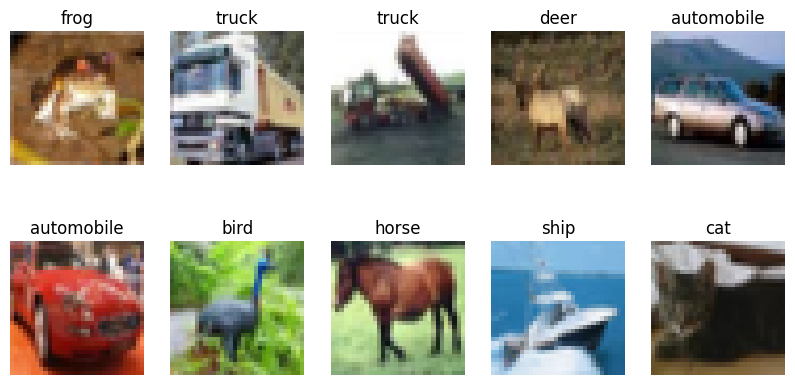

In [ ]:
plt.figure(figsize=(10,5))
for i in range(10):
  plt.subplot(2,5,i+1)
  plt.imshow(x_train[i])
  plt.title(class_names[y_train[i][0]])
  plt.axis('off')
plt.show()

In [ ]:
model=models.Sequential()

#first conv layer
model.add(layers.Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)))
model.add(layers.MaxPooling2D(2,2))

#second conv layer
model.add(layers.Conv2D(64,(3,3),activation='relu'))
model.add(layers.MaxPooling2D(2,2))

#third conv layer
model.add(layers.Conv2D(128,(3,3),activation='relu'))
# model.add(layers.MaxPooling2D(2,2))

#flatten the feature maps for the dense layers
model.add(layers.Flatten())

#Dense layer
model.add(layers.Dense(128,activation='relu'))
model.add(layers.Dropout(0.5))

#Output layer
model.add(layers.Dense(10,activation='softmax'))

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])


In [ ]:
history=model.fit(
    x_train,
    y_train,
    epochs=15,
    validation_split=0.25,
    batch_size=128,
    verbose=1
)

Epoch 1/15
293/293 ━━━━━━━━━━━━━━━━━━━━ 50s 163ms/step - accuracy: 0.3252 - loss: 1.8284 - val_accuracy: 0.4604 - val_loss: 1.5040
Epoch 2/15
293/293 ━━━━━━━━━━━━━━━━━━━━ 81s 160ms/step - accuracy: 0.4738 - loss: 1.4573 - val_accuracy: 0.5182 - val_loss: 1.3678
Epoch 3/15
293/293 ━━━━━━━━━━━━━━━━━━━━ 49s 169ms/step - accuracy: 0.5420 - loss: 1.2933 - val_accuracy: 0.5706 - val_loss: 1.2221
Epoch 4/15
293/293 ━━━━━━━━━━━━━━━━━━━━ 48s 164ms/step - accuracy: 0.5866 - loss: 1.1808 - val_accuracy: 0.6231 - val_loss: 1.0696
Epoch 5/15
293/293 ━━━━━━━━━━━━━━━━━━━━ 49s 165ms/step - accuracy: 0.6170 - loss: 1.0951 - val_accuracy: 0.6335 - val_loss: 1.0408
Epoch 6/15
293/293 ━━━━━━━━━━━━━━━━━━━━ 48s 164ms/step - accuracy: 0.6384 - loss: 1.0249 - val_accuracy: 0.6537 - val_loss: 0.9875
Epoch 7/15
293/293 ━━━━━━━━━━━━━━━━━━━━ 82s 165ms/step - accuracy: 0.6626 - loss: 0.9659 - val_accuracy: 0.6796 - val_loss: 0.9166
Epoch 8/15
293/293 ━━━━━━━━━━━━━━━━━━━━ 48s 165ms/step - accuracy: 0.6791 - loss: 0

<function matplotlib.pyplot.show(close=None, block=None)>

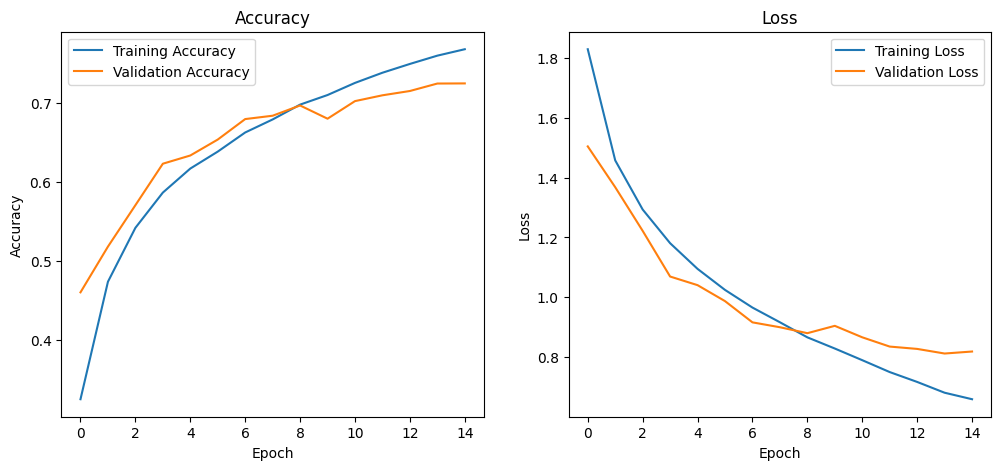

In [ ]:
plt.figure(figsize=(12,5))
#accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

#loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show

In [ ]:
test_accuracy,test_loss=model.evaluate(x_test,y_test)
print("Test Accuracy: ",test_accuracy)
print("Test Loss: ",test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.7222 - loss: 0.8154
Test Accuracy:  0.8153624534606934
Test Loss:  0.7221999764442444


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


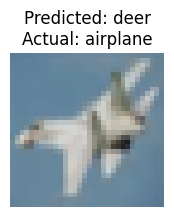

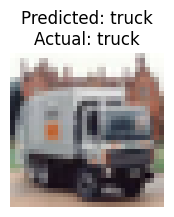

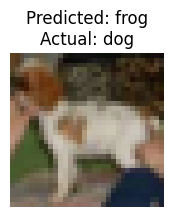

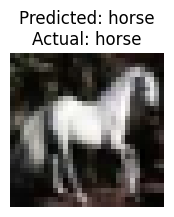

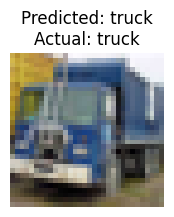

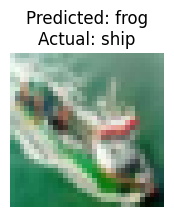

In [ ]:
predictions=model.predict(x_test)
for i in range(10,16):
  predicted_label=np.argmax(predictions[i])
  actual_label=y_test[i][0]
  plt.figure(figsize=(2,2))
  plt.imshow(x_test[i])
  plt.title(f"Predicted: {class_names[predicted_label]}\nActual: {class_names[actual_label]}")
  plt.axis('off')
  plt.show()

<Figure size 1000x1000 with 0 Axes>

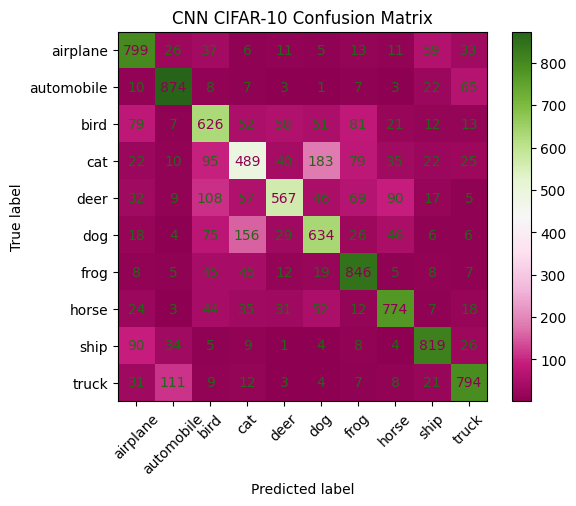

In [ ]:
y_pred=np.argmax(predictions,axis=1)
y_true=y_test.flatten()
cm=confusion_matrix(y_true,y_pred)
plt.figure(figsize=(10,10))
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=class_names)
disp.plot(cmap='PiYG',xticks_rotation=45)
plt.title("CNN CIFAR-10 Confusion Matrix")
plt.show()

#Practical Exercise 2: Ensemble CNNs


In [ ]:
def create_nn1():
  model=tf.keras.Sequential([
      layers.Conv2D(32,(3,3),activation='relu',
                    input_shape=(32,32,3)),
      layers.MaxPooling2D(2,2),
      layers.Conv2D(64,(3,3),activation='relu'),
      layers.MaxPooling2D(2,2),
      layers.Flatten(),
      layers.Dense(128,activation='relu'),
      layers.Dense(10,activation='softmax')
  ])
  return model

In [ ]:
def create_nn2():
  model=tf.keras.Sequential([
      layers.Conv2D(32,(3,3),
                    input_shape=(32,32,3)),
      layers.BatchNormalization(),
      layers.MaxPooling2D(2,2),
      layers.Conv2D(64,(3,3)),
      layers.BatchNormalization(),
      layers.Activation('relu'),
      layers.MaxPooling2D(2,2),

      layers.Conv2D(64,(3,3)),
      layers.BatchNormalization(),
      layers.Activation('relu'),
      layers.MaxPooling2D(2,2),

      layers.Flatten(),
      layers.Dense(128,activation='relu'),
      layers.Dense(10,activation='softmax'),
  ])
  return model

In [ ]:
def create_nn3():
  model=tf.keras.Sequential([
      layers.Conv2D(32,(3,3),activation='relu',
                    input_shape=(32,32,3)),
      layers.MaxPooling2D((2,2)),

      layers.Conv2D(64,(3,3),activation='relu'),
      layers.MaxPooling2D(2,2),

      layers.Flatten(),
      layers.Dense(128,activation='relu'),
      layers.Dropout(0.5),
      layers.Dense(10,activation='softmax')
  ])
  return model

In [ ]:
model1=create_nn1()
model2=create_nn2()
model3=create_nn3()

In [ ]:
for model in [model1,model2,model3]:
  model.compile(
      optimizer='adam',
      loss='sparse_categorical_crossentropy',
      metrics=['accuracy']
  )

In [ ]:
history1=model1.fit(
    x_train,y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)
history2=model2.fit(
    x_train,y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)
history3=model3.fit(
    x_train,y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 78ms/step - accuracy: 0.4547 - loss: 1.5120 - val_accuracy: 0.5639 - val_loss: 1.2444
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 73ms/step - accuracy: 0.5970 - loss: 1.1430 - val_accuracy: 0.5892 - val_loss: 1.1830
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 49s 79ms/step - accuracy: 0.6473 - loss: 1.0110 - val_accuracy: 0.6443 - val_loss: 1.0322
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 80s 77ms/step - accuracy: 0.6866 - loss: 0.9012 - val_accuracy: 0.6539 - val_loss: 1.0019
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 78ms/step - accuracy: 0.7130 - loss: 0.8300 - val_accuracy: 0.6622 - val_loss: 0.9869
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 76ms/step - accuracy: 0.7391 - loss: 0.7590 - val_accuracy: 0.6794 - val_loss: 0.9520
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 76ms/step - accuracy: 0.7598 - loss: 0.6951 - val_accuracy: 0.6924 - val_loss: 0.9150
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 87s 84ms/step - accuracy: 0.7775 - loss: 0.6403 - 

In [ ]:
pred1=model1.predict(x_test)
pred2=model2.predict(x_test)
pred3=model3.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


In [ ]:
ensemble_pred=(pred1+pred2+pred3)/3

In [ ]:
y_pred=np.argmax(ensemble_pred,axis=1)
# y_true=y_test.flatten()


In [ ]:
from sklearn.metrics import accuracy_score
a=accuracy_score(y_test,y_pred)
print("Ensemble Accuracy",a)

Ensemble Accuracy 0.7511
